In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from prysm.propagation import prepare_executor
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np

from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph

from copy import deepcopy

from astropy.io import fits

from utils import make_pinwheel, make_pinwheel_eac2, radial_profile

%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Define instrument parameters
Dpup = 6e3
Npup = 1024
Nfoc = 128
wvl = 1
fno = 15
efl = fno * Dpup
lamD = wvl / Dpup * efl
px_per_lamD = 4

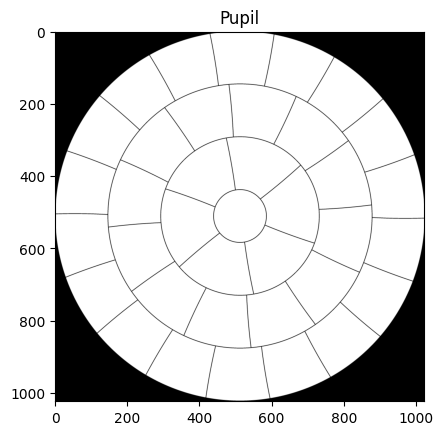

In [57]:
pupil = VariablePupil.circle(
    Dpup=Dpup,
    Npup=Npup,
    mode="amplitude" # special argument for VariablePupil
)

set_backend_to_cupy()

pinwheel = make_pinwheel(Dpup=Dpup, Npup=Npup, rings=3, segments_ring1=6, segment_separation=10)
# pinwheel = make_pinwheel_eac2(Npup=Npup, segment_separation=10)

plt.figure()
plt.title("Pupil")
plt.imshow(pinwheel.get(), cmap="gray")
plt.show()

In [58]:
# update the VariablePupil data to be a cupy array
# pupil.data = np.asarray(pupil.data)
pupil.data = np.asarray(pinwheel)
pupil.mask = np.asarray(pinwheel != 0)
pupil_base = deepcopy(pupil.data)

# Define a prysm executor the controls the propagation
executor = prepare_executor(
    pupil_dx=Dpup / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=Dpup,
    Npup=Npup,
    inner_radius=0.,
    outer_radius=0.9 * Dpup / 2
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1626251/3570181117.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_1626251/3570181117.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\lambda/D$')
/tmp/ipykernel_1626251/3570181117.py:41: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_1626251/3570181117.py:42:

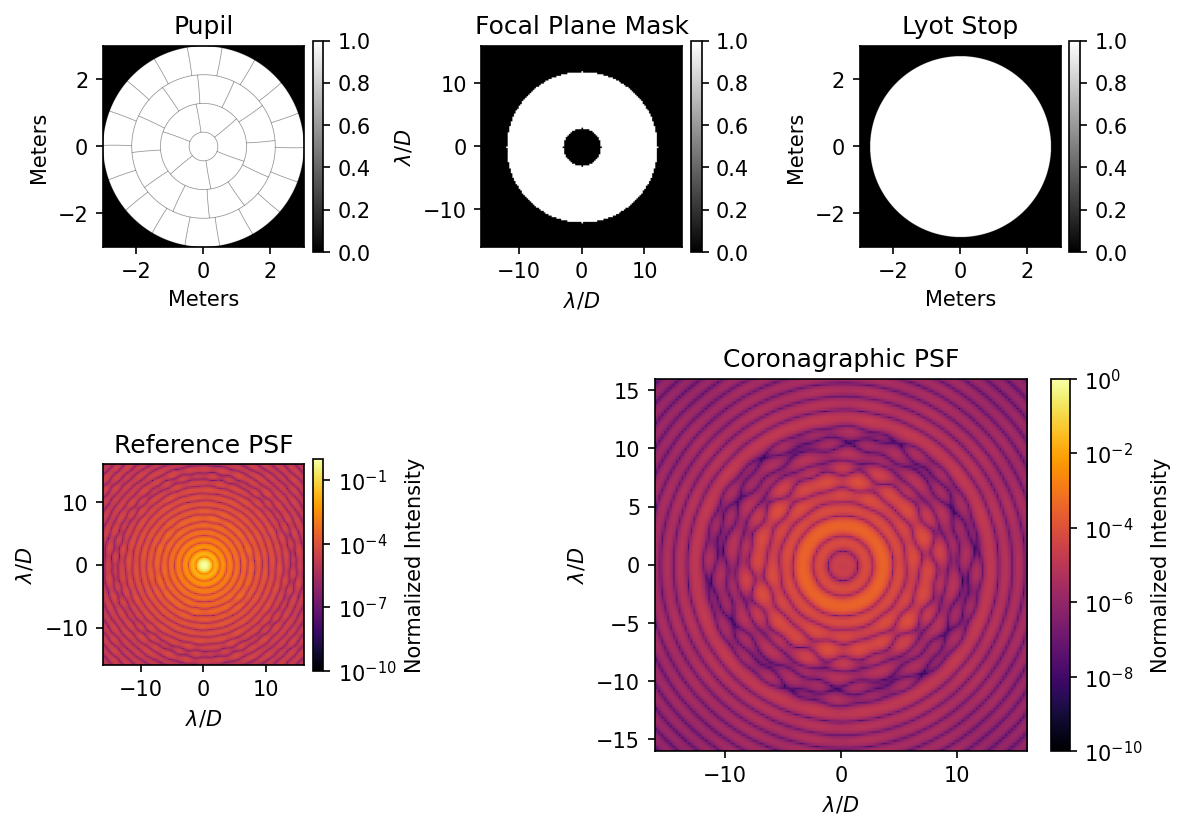

In [59]:
extent_pupil = [-Dpup / 2e3, Dpup / 2e3, 
                -Dpup / 2e3, Dpup / 2e3]
extent_focal = [-Nfoc / px_per_lamD / 2, Nfoc / px_per_lamD / 2,
                -Nfoc / px_per_lamD / 2, Nfoc / px_per_lamD / 2]

field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

fig = plt.figure(figsize=(8, 6), dpi=150, layout='tight')
gs = GridSpec(ncols=6, nrows=2, figure=fig)

ax = fig.add_subplot(gs[0, 0:2])
ax.set_title("Pupil")
im = ax.imshow(coro.pupil.data.get(), cmap="gray", extent=extent_pupil)
ax.set_xlabel('Meters')
ax.set_ylabel('Meters')
plt.colorbar(im, pad=0.04, fraction=0.048)

ax = fig.add_subplot(gs[0, 2:4])
ax.set_title("Focal Plane Mask")
im = ax.imshow(coro.fpm(wvl).get(), cmap="gray", extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.048)

ax = fig.add_subplot(gs[0, 4:6])
ax.set_title("Lyot Stop")
im = ax.imshow(coro.lyot_stop.data.get(), cmap="gray", extent=extent_pupil)
ax.set_xlabel('Meters')
ax.set_ylabel('Meters')
plt.colorbar(im, pad=0.04, fraction=0.048)

ax = fig.add_subplot(gs[1, 0:2])
ax.set_title(f"Reference PSF")
im = ax.imshow(ref_intensity.get() / contrast_norm.get(), cmap="inferno", norm='log', vmin=1e-10, vmax=1, extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.048, label='Normalized Intensity')

ax = fig.add_subplot(gs[1, 2:])
ax.set_title(f"Coronagraphic PSF")
im = ax.imshow(intensity.get(), cmap="inferno", norm='log', vmin=1e-10, vmax=1, extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.048, label='Normalized Intensity')

In [60]:
from dygdug.coropt import CoronagraphOptimizer
from dygdug.cost_functions import FieldMeanSquaredError
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Define Image Plane Sampling Specification and Dark Hole
iss = ImgSamplingSpec.from_N_lamD_px_per_lamD(Nfoc, lamD, px_per_lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
# dark_hole *= knife_edge_mask(iss, iwa=3)


# Define cost function
target_contrast = 1e-10
target_field = np.sqrt(target_contrast)
cost_function = FieldMeanSquaredError(target=target_field)

# Define the starting parameter vector
x0 = np.ones_like(pupil.data[pupil.mask], dtype="float64")

# Define the CoronagraphOptimizer
coroopt = CoronagraphOptimizer(
    dark_hole=dark_hole,
    coro=coro,
    wvl=[wvl], # just perform monochromatic for now
    cost=cost_function
)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:03<00:00, 289.32it/s]


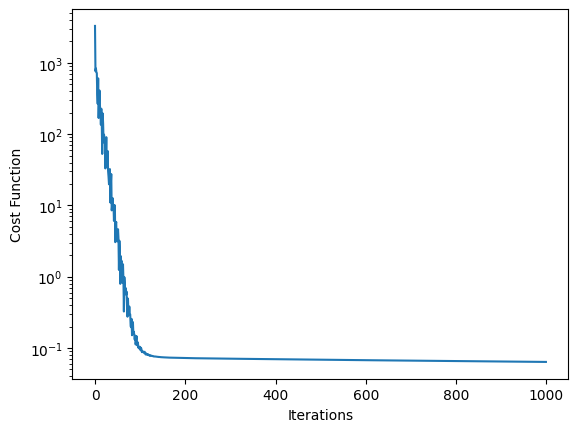

In [7]:
from tqdm import tqdm
from prysm.x.optym import Yogi, PrysmLBFGSB

upper_bounds = np.ones_like(x0)
lower_bounds = np.zeros_like(x0)

opt = Yogi(fg=coroopt.fg, x0=x0, alpha=0.5, upper_bounds=upper_bounds, lower_bounds=lower_bounds)
cost = []
N_ITER = 1000
for i in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)

xf = opt.x.copy()
pupil.update(xf)

plt.figure()
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1626251/2995365592.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_1626251/2995365592.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\lambda/D$')
/tmp/ipykernel_1626251/2995365592.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_1626251/2995365592.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\lambda/D$')
/tmp/ipykernel_1626251/299

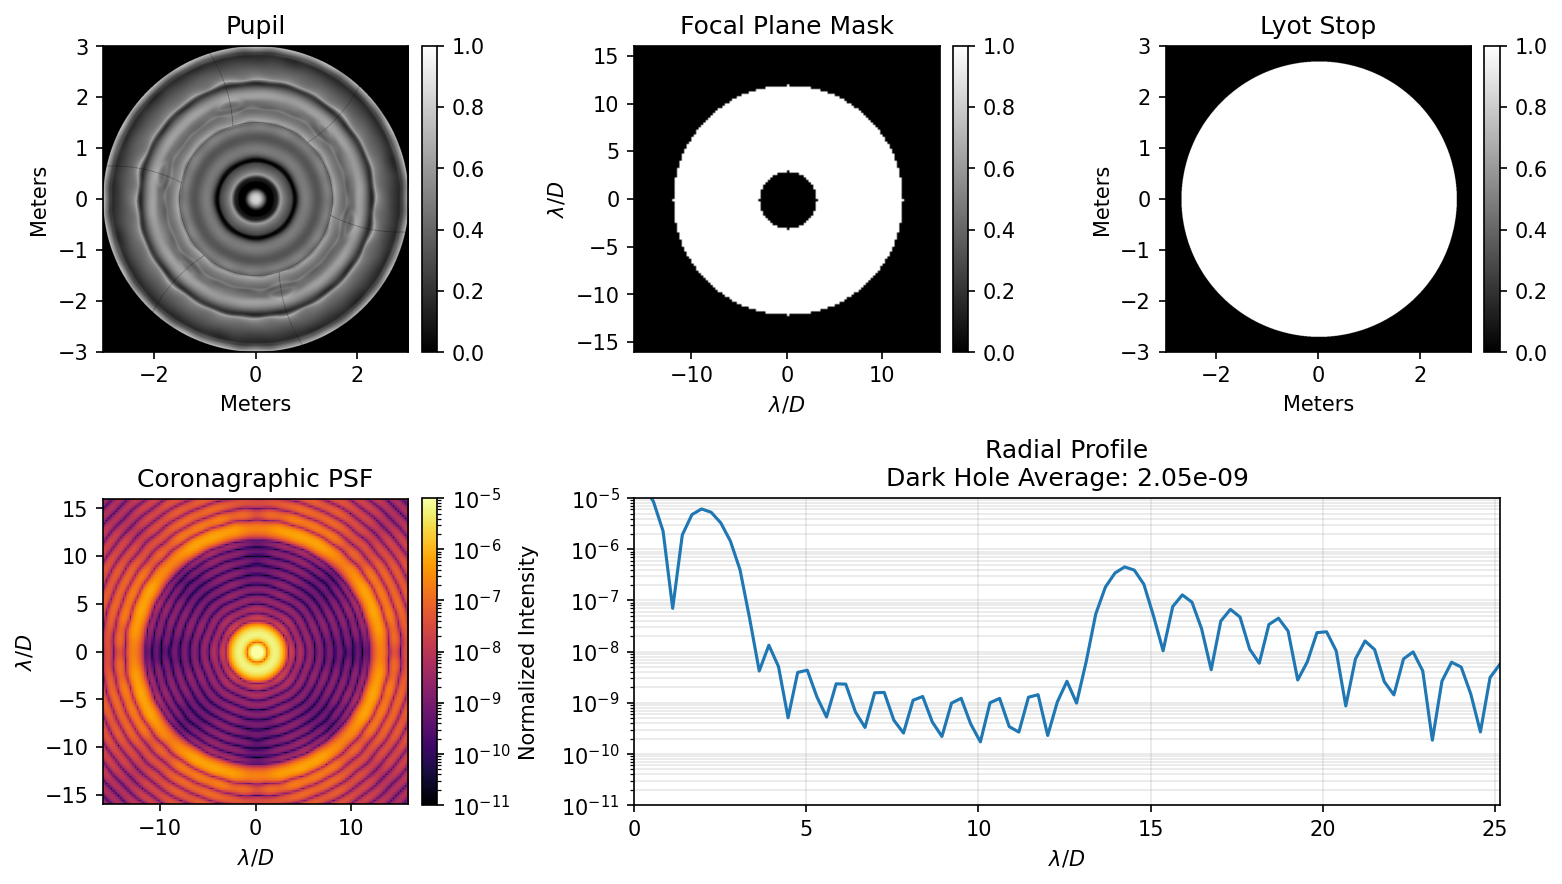

In [8]:
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm
intensity_prof = radial_profile(intensity)


fig = plt.figure(figsize=(10.5, 6), dpi=150, layout='tight')
gs = GridSpec(ncols=3, nrows=2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
ax.set_title("Pupil")
im = ax.imshow(coro.pupil.data.get(), cmap="gray", extent=extent_pupil, vmin=0, vmax=1)
ax.set_xlabel('Meters')
ax.set_ylabel('Meters')
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = fig.add_subplot(gs[0, 1])
ax.set_title("Focal Plane Mask")
im = ax.imshow(coro.fpm(wvl).get(), cmap="gray", extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = fig.add_subplot(gs[0, 2])
ax.set_title("Lyot Stop")
im = ax.imshow(coro.lyot_stop.data.get(), cmap="gray", extent=extent_pupil)
ax.set_xlabel('Meters')
ax.set_ylabel('Meters')
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = fig.add_subplot(gs[1, 0])
ax.set_title(f"Coronagraphic PSF")
im = ax.imshow(intensity.get(), cmap="inferno", norm='log', vmin=1e-11, vmax=1e-5, extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.046, label='Normalized Intensity')

ax = fig.add_subplot(gs[1, 1:])
ax.set_title(f'Radial Profile\nDark Hole Average: {np.mean(intensity[dark_hole]):.2e}')
ax.semilogy(np.linspace(0, Nfoc / px_per_lamD / 0.9 / np.sqrt(2), len(intensity_prof)).get(), intensity_prof.get())
ax.set_xlim([0, Nfoc / px_per_lamD / 0.9 / np.sqrt(2)])
ax.set_ylim([1e-11, 1e-5])
ax.set_xlabel('$\lambda/D$')
# ax.set_ylabel('Normalized Intensity')
ax.grid(which='both', alpha=0.3)

In [9]:
from dygdug.coropt import JointOptimizer, ThroughputOptimizer

# We grid-searched for this before writing the demo, don't worry about it for now
lagrange_mult = 3e-6

throughput_opt = ThroughputOptimizer(coro, alpha=lagrange_mult)

joint_opt = JointOptimizer([
    coroopt,
    throughput_opt
])

  0%|          | 0/500000 [00:00<?, ?it/s]

100%|██████████| 500000/500000 [35:09<00:00, 237.03it/s]


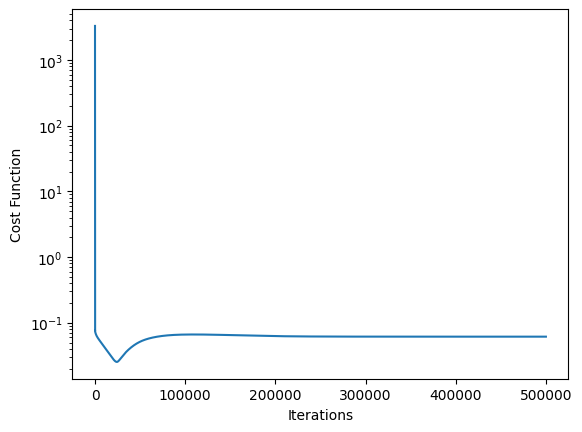

In [10]:
from tqdm import tqdm
from prysm.x.optym import Yogi, PrysmLBFGSB

upper_bounds = np.ones_like(x0)
lower_bounds = np.zeros_like(x0)

opt = Yogi(fg=joint_opt.fg, x0=x0, alpha=0.5, upper_bounds=upper_bounds, lower_bounds=lower_bounds)
cost = []
N_ITER = 500_000
for i in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)

xf = opt.x.copy()
pupil.update(xf)

plt.figure()
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")

In [11]:
fits.writeto("/home/derbyk/src/wheelies/aplc_design_pinwheel.fits", data=xf.get(), overwrite=True)

In [61]:
xf = fits.getdata("/home/derbyk/src/wheelies/aplc_design_pinwheel_big.fits")
pupil.update(xf)

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1626251/1298531812.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_1626251/1298531812.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\lambda/D$')
/tmp/ipykernel_1626251/1298531812.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda/D$')
/tmp/ipykernel_1626251/1298531812.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\lambda/D$')
/tmp/ipykernel_1626251/129

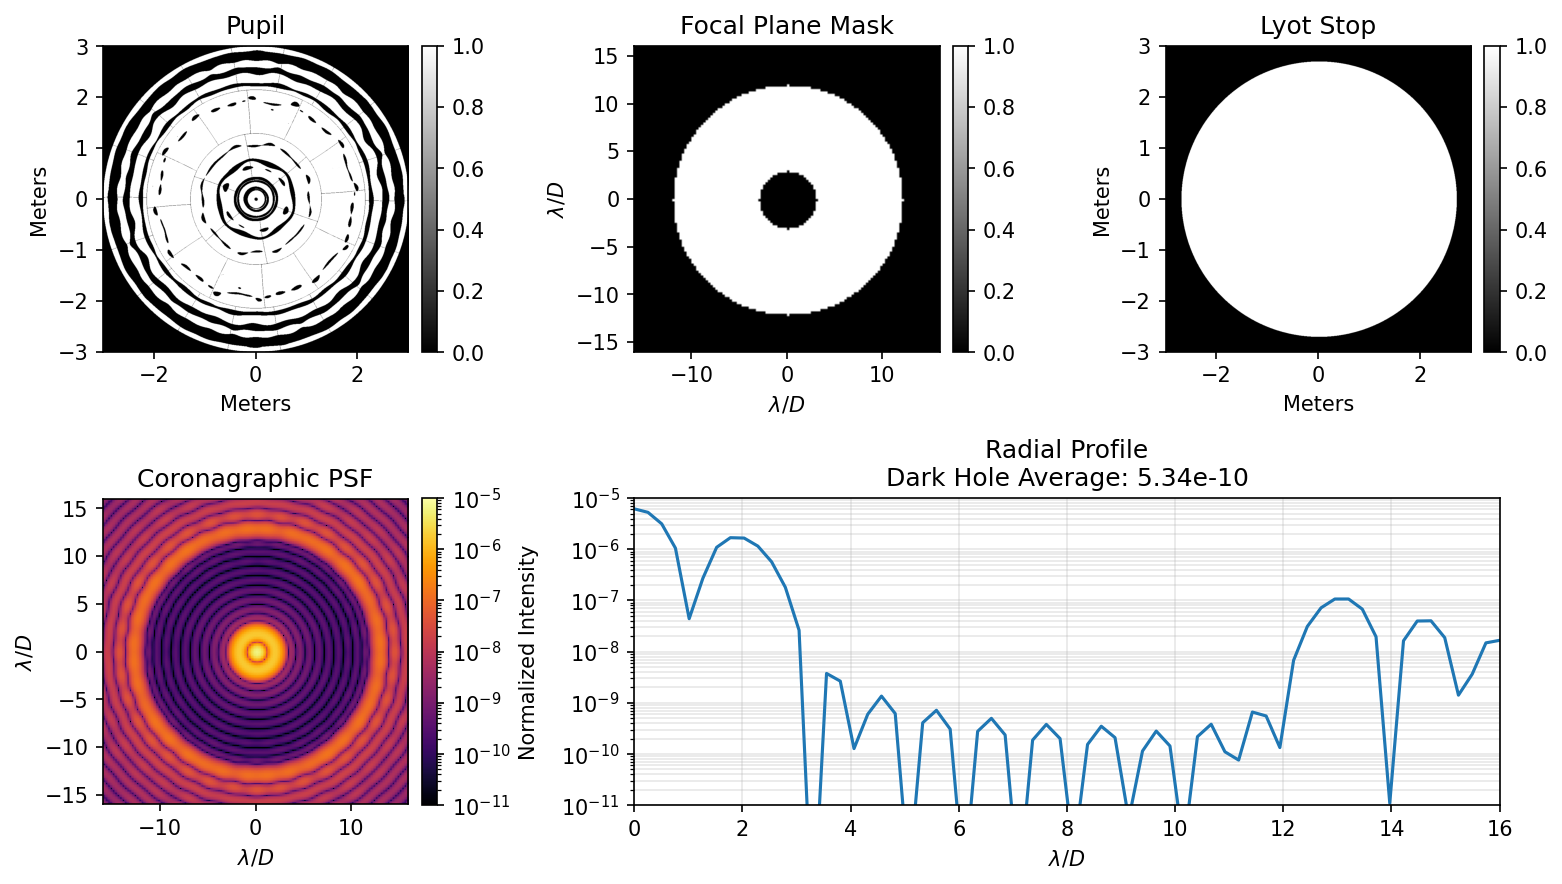

In [62]:
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm
intensity_prof = radial_profile(intensity)


fig = plt.figure(figsize=(10.5, 6), dpi=150, layout='tight')
gs = GridSpec(ncols=3, nrows=2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
ax.set_title("Pupil")
im = ax.imshow(coro.pupil.data.get(), cmap="gray", extent=extent_pupil, vmin=0, vmax=1)
ax.set_xlabel('Meters')
ax.set_ylabel('Meters')
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = fig.add_subplot(gs[0, 1])
ax.set_title("Focal Plane Mask")
im = ax.imshow(coro.fpm(wvl).get(), cmap="gray", extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = fig.add_subplot(gs[0, 2])
ax.set_title("Lyot Stop")
im = ax.imshow(coro.lyot_stop.data.get(), cmap="gray", extent=extent_pupil)
ax.set_xlabel('Meters')
ax.set_ylabel('Meters')
plt.colorbar(im, pad=0.04, fraction=0.046)

ax = fig.add_subplot(gs[1, 0])
ax.set_title(f"Coronagraphic PSF")
im = ax.imshow(intensity.get(), cmap="inferno", norm='log', vmin=1e-11, vmax=1e-5, extent=extent_focal)
ax.set_xlabel('$\lambda/D$')
ax.set_ylabel('$\lambda/D$')
plt.colorbar(im, pad=0.04, fraction=0.046, label='Normalized Intensity')

ax = fig.add_subplot(gs[1, 1:])
ax.set_title(f'Radial Profile\nDark Hole Average: {np.mean(intensity[dark_hole]):.2e}')
ax.semilogy(np.linspace(0, extent_focal[-1], int(intensity.shape[0] / 2)).get(), intensity[int(intensity.shape[0] / 2), int(intensity.shape[0] / 2):].get())
ax.set_xlim([0, extent_focal[-1]])
ax.set_ylim([1e-11, 1e-5])
ax.set_xlabel('$\lambda/D$')
# ax.set_ylabel('Normalized Intensity')
ax.grid(which='both', alpha=0.3)

In [13]:
pupil_opt = deepcopy(coro.pupil.data)

In [14]:
x = np.linspace(-0.5, 0.5, Npup)
x, y = np.meshgrid(x, x)

shifts = np.linspace(0, extent_focal[-1], 100)
throughput_abs = np.zeros_like(shifts)
throughput_rel = np.zeros_like(shifts)

for i, shift in enumerate(shifts):

    coro.pupil.data = pupil_opt * np.exp(1j * 2 * np.pi * shift * x)
    field = coro.forward(wvl=wvl, include_fpm=True)
    intensity = np.abs(field) ** 2
    intensity_pupil = np.abs(coro.pupil.data) ** 2

    throughput_abs[i] = intensity.sum() / (np.abs(pupil_base) ** 2).sum()

fits.writeto("/home/derbyk/src/wheelies/aplc_throughput_pinwheel.fits", data=throughput_abs.get(), overwrite=True)

In [18]:
shifts = np.linspace(0, extent_focal[-1], 100).get()
throughput_aplc_pin = fits.getdata("/home/derbyk/src/wheelies/aplc_throughput_pinwheel.fits")
throughput_aplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/aplc_throughput_pinwheel_big.fits")
throughput_aplc_cir = fits.getdata("/home/derbyk/src/wheelies/aplc_throughput_circ.fits")
throughput_paplc_pin = fits.getdata("/home/derbyk/src/wheelies/paplc_throughput_pinwheel.fits")
throughput_paplc_pin2 = fits.getdata("/home/derbyk/src/wheelies/paplc_throughput_pinwheel_big.fits")
throughput_paplc_cir = fits.getdata("/home/derbyk/src/wheelies/paplc_throughput_circ.fits")

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1626251/584423594.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda/D$')


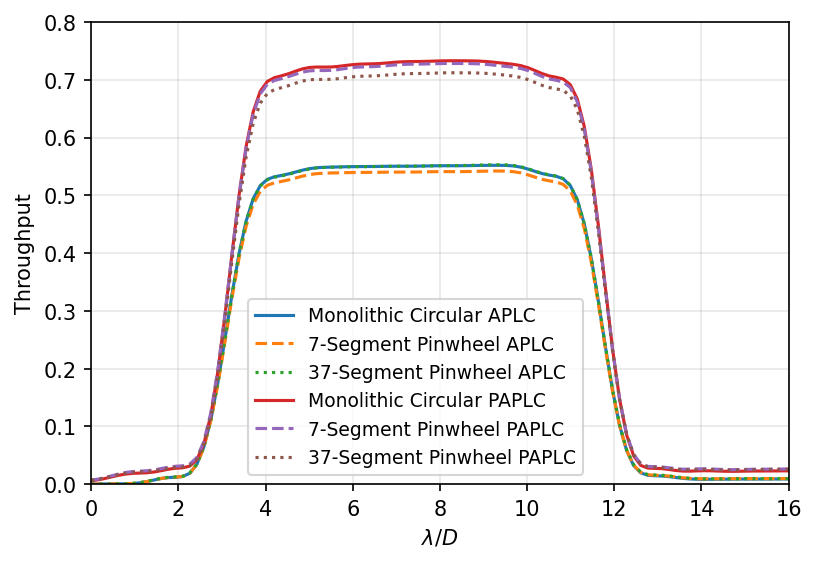

In [55]:
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(shifts, throughput_aplc_cir, label='Monolithic Circular APLC')
plt.plot(shifts, throughput_aplc_pin, label='7-Segment Pinwheel APLC', linestyle='dashed')
plt.plot(shifts, throughput_aplc_pin2, label='37-Segment Pinwheel APLC', linestyle='dotted')
plt.plot(shifts, throughput_paplc_cir, label='Monolithic Circular PAPLC')
plt.plot(shifts, throughput_paplc_pin, label='7-Segment Pinwheel PAPLC', linestyle='dashed')
plt.plot(shifts, throughput_paplc_pin2, label='37-Segment Pinwheel PAPLC', linestyle='dotted')
plt.grid(which='both', alpha=0.3)
plt.xlabel('$\lambda/D$')
plt.ylabel('Throughput')
plt.xlim([0, shifts[-1]])
plt.ylim([0, 0.8])
# plt.legend(bbox_to_anchor=(1., 0.72), loc='upper left')
plt.legend(bbox_to_anchor=(0.465, 0), loc='lower center', fontsize=9)